In [951]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [952]:
! pip install itables


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



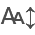

In [953]:
import itables   #rendering iteractive tables in jupyter notebook
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

# Load the dataset

In [954]:
df = pd.read_csv("heart_disease_uci - heart_disease_uci.csv")

In [955]:
df.head()

id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0

### replace the column name for better understanding

In [956]:
df.rename(columns={
    "cp":"Chest Pain",
    "trestbps":"Resting Blood Pressure",
    "chol":"Cholesterol",
    "fbs":"Fasting Blood Sugar",
    "restecg":"Resting Electrocardiographic",
    "thalach":"Maximum Heart Rate",
    "exang":"Exercise Induced Angina",
    }, inplace=True)

### print the last 5 rows in the dataset

In [957]:
df.tail()

id  age     sex        dataset       Chest Pain  Resting Blood Pressure  \
915  916   54  Female  VA Long Beach     asymptomatic                   127.0   
916  917   62    Male  VA Long Beach   typical angina                     NaN   
917  918   55    Male  VA Long Beach     asymptomatic                   122.0   
918  919   58    Male  VA Long Beach     asymptomatic                     NaN   
919  920   62    Male  VA Long Beach  atypical angina                   120.0   

     Cholesterol Fasting Blood Sugar Resting Electrocardiographic  thalch  \
915        333.0                True             st-t abnormality   154.0   
916        139.0               False             st-t abnormality     NaN   
917        223.0                True             st-t abnormality   100.0   
918        385.0                True               lv hypertrophy     NaN   
919        254.0               False               lv hypertrophy    93.0   

    Exercise Induced Angina  oldpeak slope  ca          thal  num  
915                   False      0.0   NaN NaN           NaN    1  
916                     NaN      NaN   NaN NaN           NaN    0  
917                   False      0.0   NaN NaN  fixed defect    2  
918                     NaN      NaN   NaN NaN           NaN    0  
919                    True      0.0   NaN NaN           NaN    1

### check summery

In [958]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            920 non-null    int64  
 1   age                           920 non-null    int64  
 2   sex                           920 non-null    object 
 3   dataset                       920 non-null    object 
 4   Chest Pain                    920 non-null    object 
 5   Resting Blood Pressure        861 non-null    float64
 6   Cholesterol                   890 non-null    float64
 7   Fasting Blood Sugar           830 non-null    object 
 8   Resting Electrocardiographic  918 non-null    object 
 9   thalch                        865 non-null    float64
 10  Exercise Induced Angina       865 non-null    object 
 11  oldpeak                       858 non-null    float64
 12  slope                         611 non-null    object 
 13  ca   

In [959]:
df.drop(columns=["id", "dataset", "ca", "thal"], inplace=True)


### size of the dataset

In [960]:
df.shape

(920, 12)

### check null values

In [961]:
df.isnull().sum()

age                               0
sex                               0
Chest Pain                        0
Resting Blood Pressure           59
Cholesterol                      30
Fasting Blood Sugar              90
Resting Electrocardiographic      2
thalch                           55
Exercise Induced Angina          55
oldpeak                          62
slope                           309
num                               0
dtype: int64

In [962]:
df["target"] = df["num"].apply(lambda x: 1 if x > 0 else 0)
df.drop(columns=["num"], inplace=True)  

### missing values in categorical variables

In [963]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['sex', 'Chest Pain', 'Fasting Blood Sugar',
       'Resting Electrocardiographic', 'Exercise Induced Angina', 'slope'],
      dtype='object')

In [964]:
for col in categorical_cols:
    print(col,df[col].unique())
    print("_" * 50)

sex ['Male' 'Female']
__________________________________________________
Chest Pain ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
__________________________________________________
Fasting Blood Sugar [True False nan]
__________________________________________________
Resting Electrocardiographic ['lv hypertrophy' 'normal' 'st-t abnormality' nan]
__________________________________________________
Exercise Induced Angina [False True nan]
__________________________________________________
slope ['downsloping' 'flat' 'upsloping' nan]
__________________________________________________


In [965]:
df[categorical_cols].isnull().sum()

sex                               0
Chest Pain                        0
Fasting Blood Sugar              90
Resting Electrocardiographic      2
Exercise Induced Angina          55
slope                           309
dtype: int64

### fill with mode

In [966]:
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16288\1077209983.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16288\1077209983.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].fillna(df[col].mode()[0], in

In [967]:
df[categorical_cols].isnull().sum()

sex                             0
Chest Pain                      0
Fasting Blood Sugar             0
Resting Electrocardiographic    0
Exercise Induced Angina         0
slope                           0
dtype: int64

In [968]:
for col in categorical_cols:
    print(col,df[col].unique())
    print("_" * 50)

sex ['Male' 'Female']
__________________________________________________
Chest Pain ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
__________________________________________________
Fasting Blood Sugar [ True False]
__________________________________________________
Resting Electrocardiographic ['lv hypertrophy' 'normal' 'st-t abnormality']
__________________________________________________
Exercise Induced Angina [False  True]
__________________________________________________
slope ['downsloping' 'flat' 'upsloping']
__________________________________________________


### missing values in numerical column

In [969]:
numerical_col = ["age","Resting Blood Pressure","Cholesterol","thalch","oldpeak"]

In [970]:
df[numerical_col].isnull().sum()

age                        0
Resting Blood Pressure    59
Cholesterol               30
thalch                    55
oldpeak                   62
dtype: int64

In [971]:
for col in numerical_col:
    df[col].fillna(df[col].median(), inplace=True) 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16288\2804055072.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16288\2804055072.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [972]:
df["Cholesterol"] = pd.to_numeric(df["Cholesterol"], errors="coerce")


In [973]:
print("Missing values in Cholesterol:", df["Cholesterol"].isnull().sum())
print("Zero values in Cholesterol:", (df["Cholesterol"] == 0).sum())

Missing values in Cholesterol: 0
Zero values in Cholesterol: 172


In [974]:
df["Cholesterol"] = df["Cholesterol"].replace(0, df["Cholesterol"].median())


In [975]:
df[numerical_col].isnull().sum()

age                       0
Resting Blood Pressure    0
Cholesterol               0
thalch                    0
oldpeak                   0
dtype: int64

# eda

In [976]:
df.describe().T

count        mean        std   min     25%    50%  \
age                     920.0   53.510870   9.424685  28.0   47.00   54.0   
Resting Blood Pressure  920.0  131.995652  18.451300   0.0  120.00  130.0   
Cholesterol             920.0  241.600000  52.630157  85.0  217.75  223.0   
thalch                  920.0  137.692391  25.145235  60.0  120.00  140.0   
oldpeak                 920.0    0.853261   1.058049  -2.6    0.00    0.5   
target                  920.0    0.553261   0.497426   0.0    0.00    1.0   

                          75%    max  
age                      60.0   77.0  
Resting Blood Pressure  140.0  200.0  
Cholesterol             267.0  603.0  
thalch                  156.0  202.0  
oldpeak                   1.5    6.2  
target                    1.0    1.0

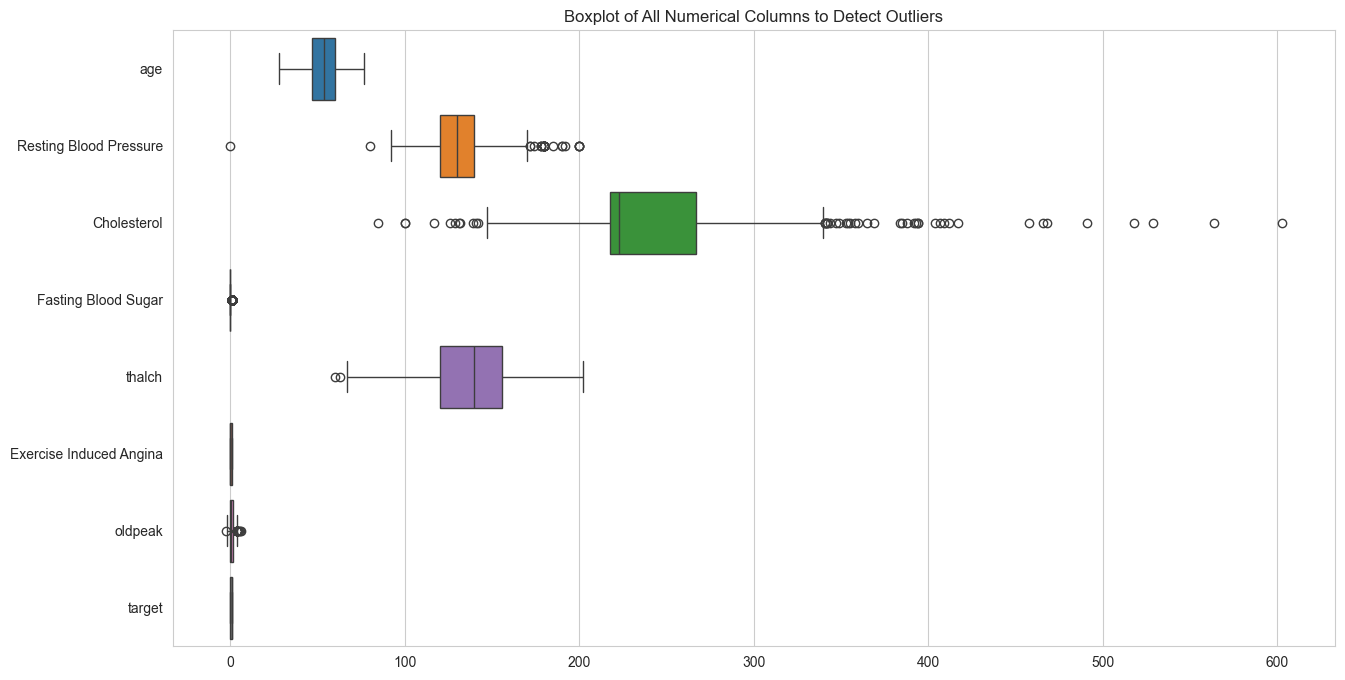

In [977]:

plt.figure(figsize=(15, 8))
sns.boxplot(data=df, orient="h")
plt.title("Boxplot of All Numerical Columns to Detect Outliers")
plt.show()

In [978]:
import numpy as np

def replace_outliers_with_median(df, exclude_columns=["chol"]):
    total_outliers_before = 0
    total_outliers_after = 0

    # Loop through numerical columns except excluded ones
    for column in df.select_dtypes(include=np.number).columns:
        if column in exclude_columns:
            continue  # Skip replacing outliers for excluded columns
        
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        # Define lower and upper bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count outliers before replacement
        outlier_count = df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]
        total_outliers_before += outlier_count

        # Compute median of column
        median_value = df[column].median()

        # ✅ Replace outliers directly in df using .loc[]
        df.loc[(df[column] < lower_bound) | (df[column] > upper_bound), column] = median_value

    # Count outliers after replacement
    for column in df.select_dtypes(include=np.number).columns:
        if column in exclude_columns:
            continue  # Skip checking excluded columns
        
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_count_after = df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]
        total_outliers_after += outlier_count_after

    print("Total outliers before replacement:", total_outliers_before)
    print("Total outliers after replacement:", total_outliers_after)
    print("Outliers successfully replaced (except for excluded columns)!\n")

    return df  # ✅ Return the modified DataFrame

# Apply function (Cholesterol values will remain unchanged)
df = replace_outliers_with_median(df)


Total outliers before replacement: 93
Total outliers after replacement: 40
Outliers successfully replaced (except for excluded columns)!



In [979]:
df = df[(df["Cholesterol"] < upper_bound) & (df["Cholesterol"] > lower_bound)]

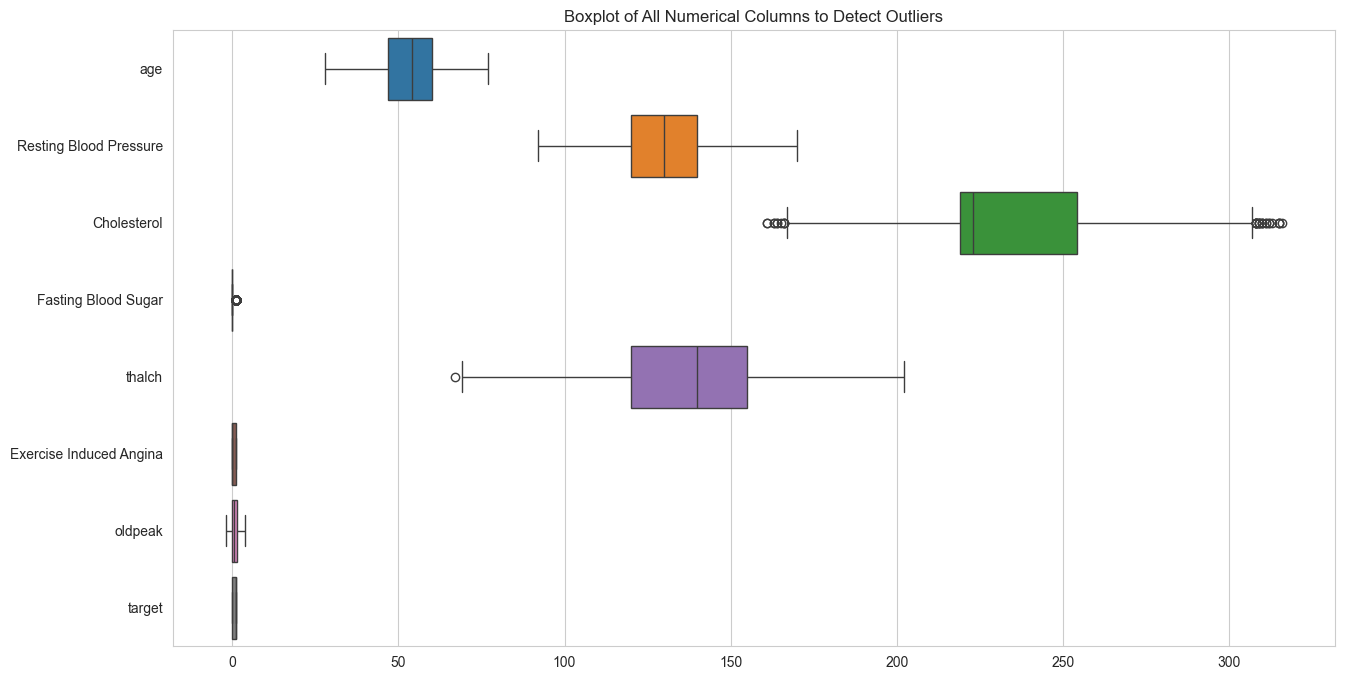

In [980]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, orient="h")
plt.title("Boxplot of All Numerical Columns to Detect Outliers")
plt.show()

### plot histogram

In [981]:

def plot_histogram(df, column, bins=30):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], bins=bins, kde=True, color="skyblue", edgecolor="black")

    # Add mean and median lines
    mean_val = df[column].mean()
    median_val = df[column].median()
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label="Mean")
    plt.axvline(median_val, color='blue', linestyle='dotted', linewidth=2, label="Median")

    plt.legend()
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()
    

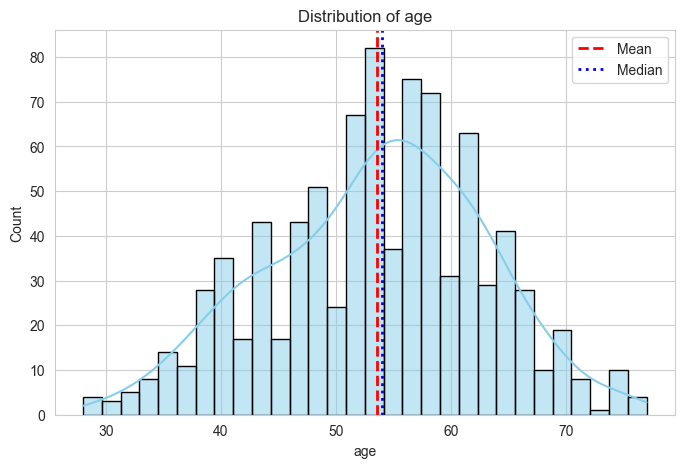

In [982]:
plot_histogram(df,"age")

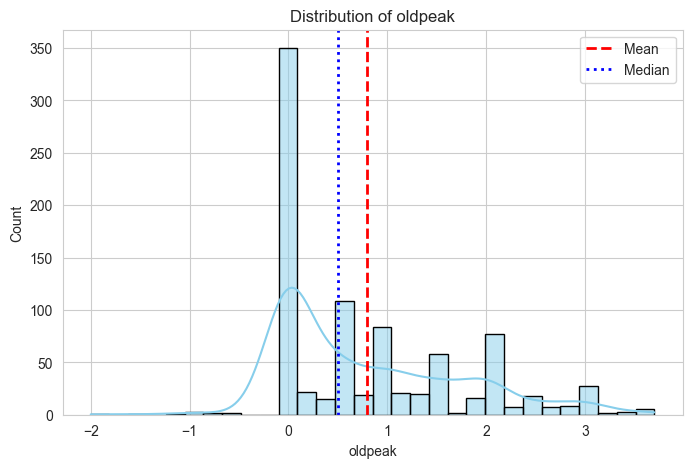

In [983]:
plot_histogram(df, "oldpeak")

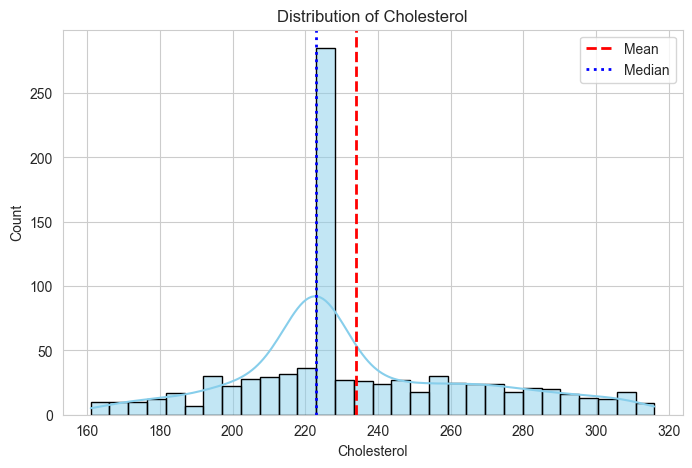

In [984]:
plot_histogram(df,"Cholesterol")

### convert categorical to numerical

In [985]:
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

In [986]:
df.sample()

age  sex  Chest Pain  Resting Blood Pressure  Cholesterol  \
394   48    0           1                   120.0        223.0   

     Fasting Blood Sugar  Resting Electrocardiographic  thalch  \
394                    1                             2   148.0   

     Exercise Induced Angina  oldpeak  slope  target  
394                        0      0.0      1       0

### split the data for training and testing

In [987]:
X= df.drop(columns="target")
y=df["target"]

In [988]:
X

age  sex  Chest Pain  Resting Blood Pressure  Cholesterol  \
0     63    1           3                   145.0        233.0   
1     67    1           0                   160.0        286.0   
2     67    1           0                   120.0        229.0   
3     37    1           2                   130.0        250.0   
4     41    0           1                   130.0        204.0   
..   ...  ...         ...                     ...          ...   
914   46    1           0                   134.0        310.0   
916   62    1           3                   130.0        223.0   
917   55    1           0                   122.0        223.0   
918   58    1           0                   130.0        223.0   
919   62    1           1                   120.0        254.0   

     Fasting Blood Sugar  Resting Electrocardiographic  thalch  \
0                      1                             0   150.0   
1                      0                             0   108.0   
2                      0                             0   129.0   
3                      0                             1   187.0   
4                      0                             0   172.0   
..                   ...                           ...     ...   
914                    0                             1   126.0   
916                    0                             2   140.0   
917                    1                             2   100.0   
918                    1                             0   140.0   
919                    0                             0    93.0   

     Exercise Induced Angina  oldpeak  slope  
0                          0      2.3      0  
1                          1      1.5      1  
2                          1      2.6      1  
3                          0      3.5      0  
4                          0      1.4      2  
..                       ...      ...    ...  
914                        0      0.0      1  
916                        0      0.5      1  
917                        0      0.0      1  
918                        0      0.5      1  
919                        1      0.0      1  

[880 rows x 11 columns]

In [989]:
y

0      0
1      1
2      1
3      0
4      0
      ..
914    1
916    0
917    1
918    0
919    1
Name: target, Length: 880, dtype: int64

### check imbalanced

In [990]:
y.value_counts()

target
1    489
0    391
Name: count, dtype: int64

In [994]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### in this dataset some columns have different units and ranges (values==magnitude). if we didnt apply standard scaler, may be the column with longer magnitude(values) might dominate those with smaller magnitude(values).this is lead to bias

In [995]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test =scaler.transform(X_test)

### train with logistic reg model

In [996]:
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

1. first predict the class labels
   * if the probability is >= 0.5, it predicts 1
   * if the probability is <= 0.5, its predict 0
2. predict_proba() returns the probability for each class.
   * Column 0: Probability of class 0
   * Column 1: Probability of class 1
3. [:, 1] selects only the probabilities for class 1 (heart disease).

In [997]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

### train with decision tree model

In [998]:
# Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

### train with random forest model

In [999]:
# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

### train with svm model

In [1000]:

# SVM Model
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

### train with xgboost model

In [1001]:
# XGBoost Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:30:04] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


### print the accurecy

In [1002]:
# Comparing Models Before Hyperparameter Tuning
models = {'logistic Regression': y_pred, 'Decision Tree': y_pred_dt, 'Random Forest': y_pred_rf, 'SVM': y_pred_svm, 'XGBoost': y_pred_xgb}
for name, y_pred in models.items():
    print(f"------------------------- {name}-------------------------")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_pred))
    print()

------------------------- logistic Regression-------------------------
              precision    recall  f1-score   support

           0       0.77      0.81      0.79        74
           1       0.86      0.82      0.84       102

    accuracy                           0.82       176
   macro avg       0.81      0.82      0.81       176
weighted avg       0.82      0.82      0.82       176

Accuracy: 0.8181818181818182
ROC AUC: 0.8171701112877583

------------------------- Decision Tree-------------------------
              precision    recall  f1-score   support

           0       0.63      0.76      0.69        74
           1       0.79      0.68      0.73       102

    accuracy                           0.71       176
   macro avg       0.71      0.72      0.71       176
weighted avg       0.72      0.71      0.71       176

Accuracy: 0.7102272727272727
ROC AUC: 0.7166136724960255

------------------------- Random Forest-------------------------
              precision    re

### Hyperparameter Tuning

In [1003]:
# Hyperparameter Tuning for Decision Tree
param_grid_dt = {'max_depth': [3, 5, 10, None], 'criterion': ['gini', 'entropy']}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

In [1004]:
# Hyperparameter Tuning for Random Forest
param_grid_rf = {'n_estimators': [50, 100, 150], 'max_depth': [None, 10, 20]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

In [1005]:
# Hyperparameter Tuning for SVM
param_grid_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(SVC(probability=True, random_state=42), param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

In [1006]:
# Hyperparameter Tuning for XGBoost
param_grid_xgb = {'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.1, 0.2]}
grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), param_grid_xgb, cv=5, scoring='accuracy')
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [1007]:

# Compare Results After Tuning
models = {'Decision Tree': y_pred_dt, 'Random Forest': y_pred_rf, 'SVM': y_pred_svm, 'XGBoost': y_pred_xgb}
for name, y_pred in models.items():
    print(f"--- {name} (After Tuning) ---")
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_pred))
    print()


--- Decision Tree (After Tuning) ---
              precision    recall  f1-score   support

           0       0.72      0.70      0.71        74
           1       0.79      0.80      0.80       102

    accuracy                           0.76       176
   macro avg       0.76      0.75      0.75       176
weighted avg       0.76      0.76      0.76       176

Accuracy: 0.7613636363636364
ROC AUC: 0.7533121356650767

--- Random Forest (After Tuning) ---
              precision    recall  f1-score   support

           0       0.80      0.81      0.81        74
           1       0.86      0.85      0.86       102

    accuracy                           0.84       176
   macro avg       0.83      0.83      0.83       176
weighted avg       0.84      0.84      0.84       176

Accuracy: 0.8352272727272727
ROC AUC: 0.8318759936406995

--- SVM (After Tuning) ---
              precision    recall  f1-score   support

           0       0.75      0.81      0.78        74
           1       0